In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from data.datasets import get_dataloader
from data.classes import CLASS_MAPPING
from models.models import PoseGRU, TwoStreamPoseGRU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [15]:
# Data loaders
train_loader = get_dataloader("data/split/train.npz", batch_size=32, shuffle=True)
val_loader = get_dataloader("data/split/val.npz", batch_size=32, shuffle=False)
test_loader = get_dataloader("data/split/test.npz", batch_size=32, shuffle=False)

# Loggign batch size
X_batch, y_batch = next(iter(train_loader))
print("Batch X:", X_batch.shape)
print("Batch y:", y_batch.shape)

Batch X: torch.Size([32, 30, 102])
Batch y: torch.Size([32])


In [16]:
# Model
input_dim = X_batch.shape[2]  
num_classes = len(CLASS_MAPPING)

model = TwoStreamPoseGRU(input_dim=input_dim, num_classes=num_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [17]:
# Training
num_epochs = 20
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/20, Train Loss: 0.9696, Val Loss: 0.3753, Val Acc: 0.8667
Epoch 2/20, Train Loss: 0.2014, Val Loss: 0.0942, Val Acc: 0.9769
Epoch 3/20, Train Loss: 0.0581, Val Loss: 0.0254, Val Acc: 0.9959
Epoch 4/20, Train Loss: 0.0123, Val Loss: 0.0022, Val Acc: 1.0000
Epoch 5/20, Train Loss: 0.0021, Val Loss: 0.0012, Val Acc: 1.0000
Epoch 6/20, Train Loss: 0.0014, Val Loss: 0.0008, Val Acc: 1.0000
Epoch 7/20, Train Loss: 0.0010, Val Loss: 0.0006, Val Acc: 1.0000
Epoch 8/20, Train Loss: 0.0007, Val Loss: 0.0005, Val Acc: 1.0000
Epoch 9/20, Train Loss: 0.0006, Val Loss: 0.0004, Val Acc: 1.0000
Epoch 10/20, Train Loss: 0.0005, Val Loss: 0.0003, Val Acc: 1.0000
Epoch 11/20, Train Loss: 0.0004, Val Loss: 0.0003, Val Acc: 1.0000
Epoch 12/20, Train Loss: 0.0003, Val Loss: 0.0002, Val Acc: 1.0000
Epoch 13/20, Train Loss: 0.0003, Val Loss: 0.0002, Val Acc: 1.0000
Epoch 14/20, Train Loss: 0.0003, Val Loss: 0.0002, Val Acc: 1.0000
Epoch 15/20, Train Loss: 0.0002, Val Loss: 0.0001, Val Acc: 1.0000
Epoc

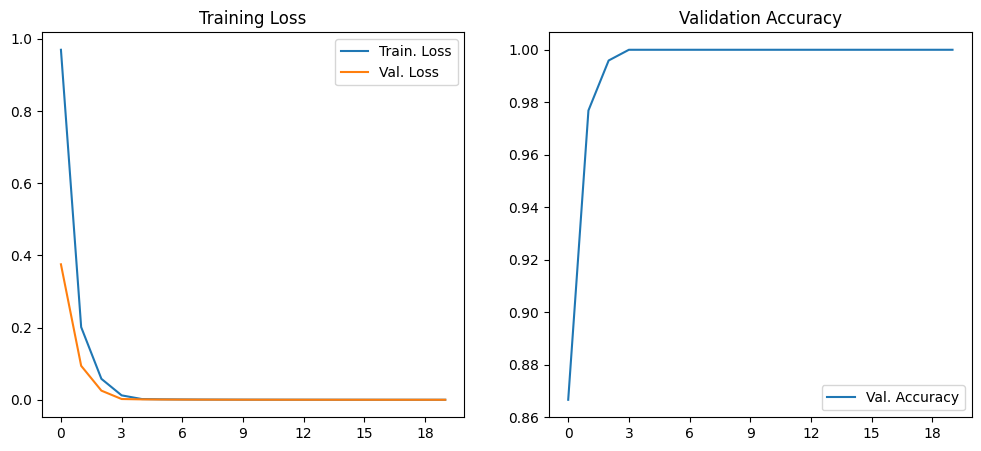

In [18]:
import matplotlib.ticker as mticker

# Learning curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train. Loss")
plt.plot(val_losses, label="Val. Loss")
plt.legend()
plt.title("Training Loss")

# integer ticks on x-axis (epochs)
ax1 = plt.gca()
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val. Accuracy")
plt.legend()
plt.title("Validation Accuracy")

# integer ticks on x-axis (epochs)
ax2 = plt.gca()
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       117
           1       1.00      1.00      1.00       116
           2       1.00      1.00      1.00       117
           3       1.00      1.00      1.00       116
           4       1.00      1.00      1.00       121
           5       1.00      1.00      1.00       149

    accuracy                           1.00       736
   macro avg       1.00      1.00      1.00       736
weighted avg       1.00      1.00      1.00       736



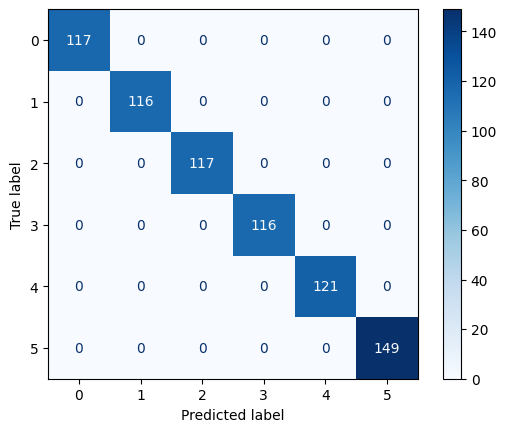

In [6]:
# Test 
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [7]:
# Save model
torch.save(model.state_dict(), "trained_models/2s_pose_gru_6class.pt")
print("Saved in trained_models")

Saved in trained_models
